   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 MB 8.7 MB/s eta 0:00:00
Running Monte Carlo: 100 trials × 4300 steps...
  20/100 done
  40/100 done
  60/100 done
  80/100 done
  100/100 done
Monte Carlo complete.

Monte Carlo Results — 100 trials
Arc-length:  mean=0.247 m,  std=0.010 m,  max=1.537 m
Lateral:     mean=0.031 m,  std=0.004 m,  max=0.162 m
Velocity:    mean=2.103 m/s, std=0.098 m/s


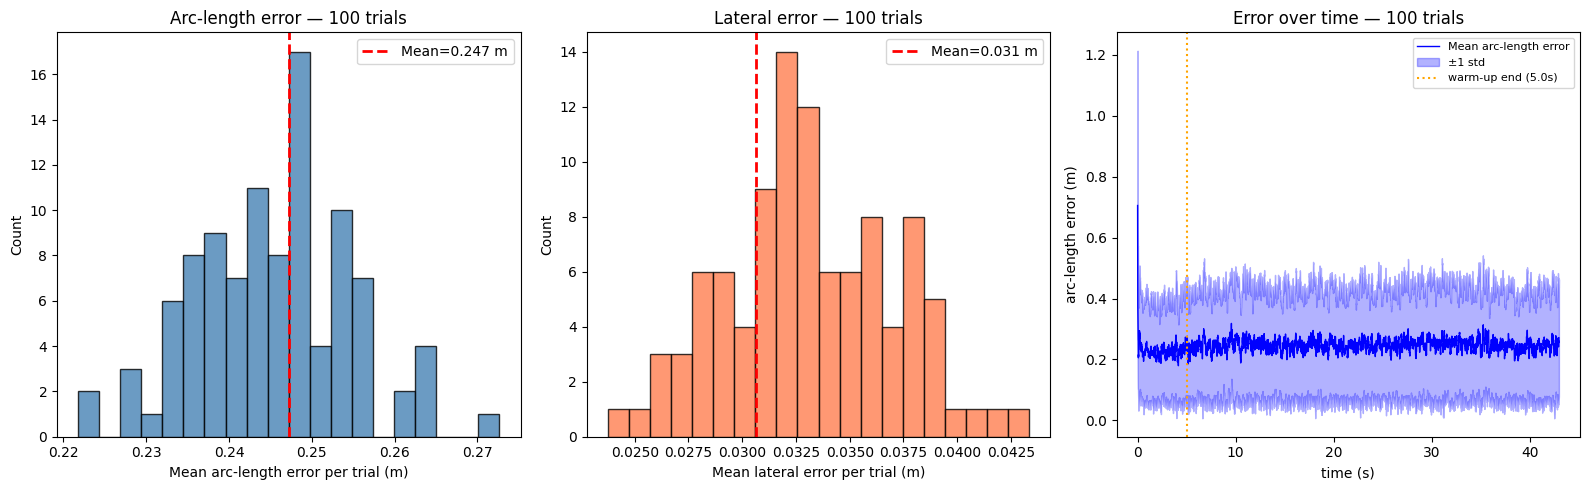

In [1]:
!pip install casadi -q

import numpy as np
import matplotlib.pyplot as plt
import casadi.casadi as cs

np.random.seed(42)

# ── Track geometry (A1, modelling.ipynb — ChenhuiCui) ─────────────────────
R_outer = 50.0; r_inner = 46.0; rho = 20.0; d = 100.0
R_A = (R_outer + r_inner) / 2
w   = (R_outer - r_inner) / 2
R_B = rho + w
alpha = np.arcsin((R_A - R_B) / d)
cos_a  = np.cos(alpha);  sin_a = np.sin(alpha)
l_tan  = np.sqrt(d**2 - (R_A - R_B)**2)
L      = 2*l_tan + R_A*(np.pi + 2*alpha) + R_B*(np.pi - 2*alpha)
s1     = l_tan;  s2 = s1 + R_B*(np.pi - 2*alpha);  s3 = s2 + l_tan

A_centre = np.array([0.0, 0.0]);  B_centre = np.array([d, 0.0])
A_top    = A_centre + R_A * np.array([sin_a,  cos_a])
B_bot    = B_centre + R_B * np.array([sin_a, -cos_a])

def s_to_xy(s):
    s = s % L
    if s < s1:
        return A_top + s * np.array([cos_a, -sin_a])
    elif s < s2:
        theta = (np.pi/2 - alpha) - (s - s1) / R_B
        return B_centre + R_B * np.array([np.cos(theta), np.sin(theta)])
    elif s < s3:
        return B_bot + (s - s2) * np.array([-cos_a, -sin_a])
    else:
        theta = (-np.pi/2 + alpha) - (s - s3) / R_A
        return A_centre + R_A * np.array([np.cos(theta), np.sin(theta)])

def s_to_normal(s):
    s = s % L
    if s < s1:
        return np.array([sin_a,  cos_a])
    elif s < s2:
        theta = (np.pi/2 - alpha) - (s - s1) / R_B
        return np.array([np.cos(theta), np.sin(theta)])
    elif s < s3:
        return np.array([sin_a, -cos_a])
    else:
        theta = (-np.pi/2 + alpha) - (s - s3) / R_A
        return np.array([np.cos(theta), np.sin(theta)])

def sl_to_xy(s, ell):
    return s_to_xy(s) + ell * s_to_normal(s)

# ── Problem data (A2/A3/A4, modelling.ipynb — ChenhuiCui) ─────────────────
dt     = 0.01
phi_vs = 0.999
phi_1  = 0.9
k2     = 10.0

anchors = np.array([
    [ -14.3,  63.6],
    [ 114.3,  45.5],
    [  28.6, -63.6],
    [ -57.1,   9.1],
    [  92.9, -45.5],
])
ny = len(anchors)
nx = 4

A = np.array([
    [1,       0,     dt,       0   ],
    [0,       1,     0,        dt  ],
    [0,       0,     phi_vs,   0   ],
    [0, -dt*k2,     0,        phi_1],
])
G = np.array([[0,0],[0,0],[1,0],[0,1]])

Q    = np.diag([0.5, 0.003])   # confirmed by A4 (modelling.ipynb, Cell 24)
R    = 1.5**2 * np.eye(ny)
Qbar = G @ Q @ G.T

def f(x, w):
    x_plus     = A @ x
    x_plus[2] += 10.0 * (1 - phi_vs)   # nominal velocity drift (align EKF with true dynamics)
    x_plus[2] += w[0]
    x_plus[3] += w[1]
    x_plus[1]  = np.clip(x_plus[1], -2.0, 2.0)
    x_plus[2]  = np.clip(x_plus[2],  0.001, 25.0)
    return x_plus
# ── Create function h(z, v) using casadi ───────────────────────────────────
z_ = cs.SX.sym('z_', nx)
v_ = cs.SX.sym('v_', ny)

s_mod  = cs.fmod(z_[0], L)
ell_   = z_[1]

theta2_ = (np.pi/2 - alpha) - (s_mod - s1) / R_B
theta4_ = (-np.pi/2 + alpha) - (s_mod - s3) / R_A

xy1_ = cs.vertcat(A_top[0] + s_mod*cos_a,            A_top[1] - s_mod*sin_a)
xy2_ = cs.vertcat(B_centre[0] + R_B*cs.cos(theta2_), R_B*cs.sin(theta2_))
xy3_ = cs.vertcat(B_bot[0] - (s_mod-s2)*cos_a,       B_bot[1] - (s_mod-s2)*sin_a)
xy4_ = cs.vertcat(R_A*cs.cos(theta4_),                R_A*cs.sin(theta4_))
xy_c = cs.if_else(s_mod < s1, xy1_,
       cs.if_else(s_mod < s2, xy2_,
       cs.if_else(s_mod < s3, xy3_, xy4_)))

n1_ = cs.vertcat(sin_a,  cos_a)
n2_ = cs.vertcat(cs.cos(theta2_), cs.sin(theta2_))
n3_ = cs.vertcat(sin_a, -cos_a)
n4_ = cs.vertcat(cs.cos(theta4_), cs.sin(theta4_))
n_c = cs.if_else(s_mod < s1, n1_,
      cs.if_else(s_mod < s2, n2_,
      cs.if_else(s_mod < s3, n3_, n4_)))

r_  = xy_c + ell_ * n_c
h_  = cs.vertcat(*[cs.norm_2(r_ - anchors[i]) + v_[i] for i in range(ny)])

# Determination of the Jacobian matrix of h
jhx = cs.jacobian(h_, z_)
jhv = cs.jacobian(h_, v_)
jhx = cs.Function('jhx', [z_, v_], [jhx])
jhv = cs.Function('jhv', [z_, v_], [jhv])

# Create a Function object for h
h = cs.Function('h', [z_, v_], [h_])

# ── EKF ────────────────────────────────────────────────────────────────────
def measurement_update(sigma_t_pred, x_t_pred, y_t):
    C            = jhx(x_t_pred, 0)
    Rv           = jhv(x_t_pred, 0)
    Z            = C @ sigma_t_pred @ C.T + Rv @ R @ Rv.T
    x_t_meas     = x_t_pred + sigma_t_pred @ C.T @ np.linalg.solve(Z, y_t - h(x_t_pred, [0]*ny))
    sigma_t_meas = sigma_t_pred - sigma_t_pred @ C.T @ np.linalg.solve(Z, C @ sigma_t_pred)
    return np.array(sigma_t_meas), np.array(x_t_meas).flatten()

def time_update(sigma_t_meas, x_t_meas):
    x_t_pred     = f(x_t_meas, np.zeros(2))
    sigma_t_pred = A @ sigma_t_meas @ A.T + Qbar
    return np.array(sigma_t_pred), np.array(x_t_pred).flatten()

# ── B2: Monte Carlo simulation ─────────────────────────────────────────────
N_trials = 100
N        = 4300

arc_err_all = np.zeros((N_trials, N-1))
lat_err_all = np.zeros((N_trials, N-1))
vs_err_all  = np.zeros((N_trials, N-1))

print("Running Monte Carlo: 100 trials × 4300 steps...")

for trial in range(N_trials):
    np.random.seed(trial)

    x_t          = np.array([0.0, 0.0, 10.0, 0.0])
    x_t_pred     = np.array([0.0, 0.0, 10.0, 0.0])
    sigma_t_pred = np.diag([100.0, 1.0, 25.0, 0.5])

    x_cache_tr       = np.zeros((N, nx))
    x_meas_cache_tr  = np.zeros((N-1, nx))
    x_cache_tr[0, :] = x_t.T

    for t in range(N-1):
        # i. obtain measurement
        v_t = np.random.normal(0, 1.5, ny)
        y_t = h(x_t, v_t)

        # ii. measurement update
        sigma_t_meas, x_t_meas    = measurement_update(sigma_t_pred, x_t_pred, y_t)
        x_meas_cache_tr[t, :]      = x_t_meas.T

        # iii. Time update
        sigma_t_pred, x_t_pred = time_update(sigma_t_meas, x_t_meas)

        # iv. Dynamics
        w_t     = np.array([np.random.normal(0, np.sqrt(Q[0, 0])),
                            np.random.normal(0, np.sqrt(Q[1, 1]))])
        vs_new  = phi_vs * x_t[2] + 10.0*(1 - phi_vs) + w_t[0]
        vl_new  = phi_1  * x_t[3] - dt*k2 * x_t[1]   + w_t[1]
        vs_new  = np.clip(vs_new,  0.001, 25.0)
        vl_new  = np.clip(vl_new, -0.55,  0.55)
        ell_new = np.clip(x_t[1] + dt*x_t[3], -2.0, 2.0)
        x_t     = np.array([x_t[0] + dt*x_t[2], ell_new, vs_new, vl_new])
        x_cache_tr[t+1, :] = x_t.T

    arc_err_all[trial] = np.abs(x_cache_tr[:-1, 0] - x_meas_cache_tr[:, 0])
    lat_err_all[trial] = np.abs(x_cache_tr[:-1, 1] - x_meas_cache_tr[:, 1])
    vs_err_all[trial]  = np.abs(x_cache_tr[:-1, 2] - x_meas_cache_tr[:, 2])

    if (trial+1) % 20 == 0:
        print(f"  {trial+1}/100 done")

print("Monte Carlo complete.")

# ── Statistics ─────────────────────────────────────────────────────────────
warmup = 500   # 5 s — P0 diffuse, first ~5s dominated by initial transient

arc_mean = np.mean(arc_err_all[:, warmup:])
arc_std  = np.std(np.mean(arc_err_all[:, warmup:], axis=1))
arc_max  = np.max(arc_err_all[:, warmup:])
lat_mean = np.mean(lat_err_all[:, warmup:])
lat_std  = np.std(np.mean(lat_err_all[:, warmup:], axis=1))
lat_max  = np.max(lat_err_all[:, warmup:])
vs_mean  = np.mean(vs_err_all[:, warmup:])
vs_std   = np.std(np.mean(vs_err_all[:, warmup:], axis=1))

print("\n" + "="*55)
print("Monte Carlo Results — 100 trials")
print("="*55)
print(f"Arc-length:  mean={arc_mean:.3f} m,  std={arc_std:.3f} m,  max={arc_max:.3f} m")
print(f"Lateral:     mean={lat_mean:.3f} m,  std={lat_std:.3f} m,  max={lat_max:.3f} m")
print(f"Velocity:    mean={vs_mean:.3f} m/s, std={vs_std:.3f} m/s")
print("="*55)

# ── Plots ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

per_trial_arc = np.mean(arc_err_all, axis=1)
axes[0].hist(per_trial_arc, bins=20, color='steelblue', edgecolor='k', alpha=0.8)
axes[0].axvline(arc_mean, color='r', ls='--', lw=2, label=f'Mean={arc_mean:.3f} m')
axes[0].set_xlabel('Mean arc-length error per trial (m)')
axes[0].set_ylabel('Count')
axes[0].set_title('Arc-length error — 100 trials')
axes[0].legend()

per_trial_lat = np.mean(lat_err_all, axis=1)
axes[1].hist(per_trial_lat, bins=20, color='coral', edgecolor='k', alpha=0.8)
axes[1].axvline(lat_mean, color='r', ls='--', lw=2, label=f'Mean={lat_mean:.3f} m')
axes[1].set_xlabel('Mean lateral error per trial (m)')
axes[1].set_ylabel('Count')
axes[1].set_title('Lateral error — 100 trials')
axes[1].legend()

t_ax      = np.arange(N-1) * dt
arc_tmean = np.mean(arc_err_all, axis=0)
arc_tstd  = np.std(arc_err_all,  axis=0)
axes[2].plot(t_ax, arc_tmean, 'b', lw=1, label='Mean arc-length error')
axes[2].fill_between(t_ax,
                     arc_tmean - arc_tstd,
                     arc_tmean + arc_tstd,
                     alpha=0.3, color='blue', label='±1 std')
axes[2].axvline(warmup*dt, color='orange', ls=':', lw=1.5,
                label=f'warm-up end ({warmup*dt:.1f}s)')
axes[2].set_xlabel('time (s)')
axes[2].set_ylabel('arc-length error (m)')
axes[2].set_title('Error over time — 100 trials')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()